# Statistical Abstractions - Technical Overview

This notebook explains the statistical abstraction layer implemented in `malthusjax.benchmarking.statistics` and how to use it for parity-style comparisons.

**What you'll learn:**
- Design goals and architecture
- `StatisticalComparisonSpec` and hypothesis configuration
- `PairedMetricDataset` construction pathways
- Per-pair comparison via `StatisticalComparator.compare_paired`
- Suite-level correction via `compare_suite` + Holm/FDR
- Exporting and interpreting markdown/JSON summaries

## Part 1: Why this abstraction exists

The module separates *statistical intent* from *data source*:

1. **Intent**: hypothesis family, sidedness, expected direction, alpha, correction policy.
2. **Data**: paired arrays aligned by common seed set, from experiments/comparisons/artifacts.
3. **Decision**: standardized tests + effect sizes + decision rule.

This keeps parity analyses reproducible and consistent across scripts.

In [15]:
# Setup imports
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from malthusjax.benchmarking.statistics import (
    EffectSizeResult,
    ExpectedDirection,
    HypothesisKind,
    MultipleTestingPolicy,
    PairedMetricDataset,
    Sidedness,
    StatisticalComparator,
    StatisticalComparisonSpec,
    adjust_pvalues,
    attach_adjusted_pvalues,
    compare_paired_arrays,
    compute_effect_sizes,
    compute_standard_tests,
    infer_scipy_alternative,
    paired_dataset_from_comparison,
    validate_spec,
)
from malthusjax.composer import Composer

print('Imports OK')

Imports OK


## Part 2: Spec layer (`StatisticalComparisonSpec`)

`StatisticalComparisonSpec` is the single source of truth for inferential settings.

Key fields:
- `hypothesis_kind`: `location_shift`, `closer_to_optimum`, `equivalence`
- `sidedness`: `two_sided` or `one_sided`
- `expected_direction`: `left_lt_right` or `left_gt_right`
- `alpha`, `min_paired_seeds`
- `multiple_testing`: `none`, `holm`, `fdr_bh`
- report toggles: `include_value_lists`, `include_timing_stats`, `include_mean_summary`

In [2]:
# Example spec definitions and validation
spec_location = StatisticalComparisonSpec(
    metric_name='best_fitness',
    hypothesis_kind=HypothesisKind.LOCATION_SHIFT,
    sidedness=Sidedness.TWO_SIDED,
    expected_direction=ExpectedDirection.LEFT_LT_RIGHT,
    alpha=0.05,
    min_paired_seeds=10,
    multiple_testing=MultipleTestingPolicy.HOLM,
)

spec_equivalence = StatisticalComparisonSpec(
    metric_name='best_fitness',
    hypothesis_kind=HypothesisKind.EQUIVALENCE,
    equivalence_margin=0.10,
    alpha=0.05,
    min_paired_seeds=10,
)

validate_spec(spec_location)
validate_spec(spec_equivalence)

print('location alternative =', infer_scipy_alternative(spec_location.sidedness,
                                                        spec_location.expected_direction))
print('Specs validated')

location alternative = two-sided
Specs validated


## Part 3: Core test/effect primitives

At the lowest level:
- `compute_standard_tests(...)` calculates Wilcoxon, paired t, sign test
- `compute_effect_sizes(...)` calculates paired Cohen dz and rank-biserial
- `compare_paired_arrays(...)` ties tests + decision rule into one `StatisticalComparisonResult`

In [3]:
# Synthetic paired sample (lower is better)
rng = np.random.default_rng(7)
left = rng.normal(loc=0.85, scale=0.10, size=30)
right = rng.normal(loc=0.90, scale=0.10, size=30)

tests = compute_standard_tests(
    left=left,
    right=right,
    alternative='two-sided',
    include_tests=('wilcoxon', 'paired_t', 'sign'),
)
effects = compute_effect_sizes(left, right)

print('wilcoxon p =', tests['wilcoxon'].p_value)
print('paired_t p =', tests['paired_t'].p_value)
print('cohen dz =', effects.cohen_dz)
print('rank-biserial =', effects.rank_biserial)
print('is EffectSizeResult =', isinstance(effects, EffectSizeResult))

wilcoxon p = 0.0009517744183540344
paired_t p = 0.0006688795754904653
cohen dz = -0.6955661864560997
rank-biserial = -0.5333333333333333
is EffectSizeResult = True


In [4]:
# Full comparison result from paired arrays
result = compare_paired_arrays(
    label='demo_left_vs_right',
    left_name='MalthusJAX',
    right_name='EvoSAX',
    left=left,
    right=right,
    spec=spec_location,
    metadata={'note': 'synthetic demo'},
)

print('decision_pass =', result.decision_pass)
print('decision_basis =', result.decision_basis)
print('wins_left / wins_right / ties =', result.wins_left, result.wins_right, result.ties)
print('mean_diff_left_minus_right =', result.mean_diff_left_minus_right)

decision_pass = False
decision_basis = wilcoxon_two-sided
wins_left / wins_right / ties = 23 7 0
mean_diff_left_minus_right = -0.09094454142751784


## Part 4: Dataset abstraction (`PairedMetricDataset`)

`PairedMetricDataset` is the neutral paired payload consumed by the comparator.

In production, construct it via adapters:
- `paired_dataset_from_experiments(...)`
- `paired_dataset_from_comparison(...)`
- `paired_dataset_from_artifacts(...)`

Below we build one manually for an API-focused demonstration.

In [5]:
dataset = PairedMetricDataset(
    label='sphere_malthusjax_vs_sphere_evosax',
    left_name='sphere_malthusjax',
    right_name='sphere_evosax',
    seeds=list(range(30)),
    left_values=left,
    right_values=right,
    metric_name='best_fitness',
    metric_source='synthetic',
    metadata={'left_start_mean': 1.2, 'right_start_mean': 1.2},
)

print('dataset label =', dataset.label)
print('n paired =', len(dataset.seeds))

dataset label = sphere_malthusjax_vs_sphere_evosax
n paired = 30


## Part 5: Comparator API

`StatisticalComparator` provides:
- `compare_paired(dataset, spec)` -> `StatisticalComparisonResult`
- `compare_suite([datasets...], spec)` -> `StatisticalSuiteResult`

Below we build a **live suite from `Composer.compare(...)` results** (no legacy artifact files).

In [16]:
comparator = StatisticalComparator()
single = comparator.compare_paired(dataset, spec_location)
print('single decision:', single.decision_pass, '| basis:', single.decision_basis)

# Build a live suite from Composer.compare outputs (no precomputed artifacts)
composer = Composer.create_default()

# Demo runs are intentionally tiny for notebook speed, so we relax paired minimum here.
spec_live = StatisticalComparisonSpec(
    metric_name=spec_location.metric_name,
    hypothesis_kind=spec_location.hypothesis_kind,
    sidedness=spec_location.sidedness,
    expected_direction=spec_location.expected_direction,
    alpha=spec_location.alpha,
    min_paired_seeds=1,
    multiple_testing=spec_location.multiple_testing,
    include_tests=spec_location.include_tests,
)

live_benchmarks = [
    ('sphere_live', 'sphere:dim=10'),
    ('rastrigin_live', 'rastrigin:dim=10'),
    ('rosenbrock_live', 'rosenbrock:dim=10'),
]

suite_datasets = []
for tag, fitness_spec in live_benchmarks:
    left_name = f'{tag}_malthusjax'
    right_name = f'{tag}_evosax'

    comparison = composer.compare(
        pipelines={
            left_name: {
                'backend': 'malthusjax',
                'selection': 'tournament:num_selections=16,tournament_size=3',
                'crossover': 'blend:alpha=0.5',
                'mutation': 'gaussian:mutation_rate=0.1',
            },
            right_name: {
                'backend': 'evosax',
                'evosax_strategy': 'SimpleGA',
            },
        },
        seeds=(42,),
        shared_initial_population=True,
        pop_seed=123,
        fitness=fitness_spec,
        pop_size=32,
        generations=8,
        genome_length=10,
        maximize=False,
    )

    ds = paired_dataset_from_comparison(
        comparison=comparison,
        left_pipeline=left_name,
        right_pipeline=right_name,
        spec=spec_live,
    )
    suite_datasets.append(ds)

suite = comparator.compare_suite(suite_datasets, spec_live)
print('suite results:', len(suite.results))
print('dataset labels:', [d.label for d in suite_datasets])
print('adjusted keys example:', list(suite.adjusted_p_values.keys())[:2])

single decision: False | basis: wilcoxon_two-sided


python(12613) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
pipelines:   0%|          | 0/2 [00:00<?, ?it/s]

  - Seed 1/1 start (seed=42)
  - Seed 1/1 done status=success duration=21.09s


pipelines:  50%|█████     | 1/2 [00:23<00:23, 23.35s/it]

  - Seed 1/1 start (seed=42)
  - Seed 1/1 done status=success duration=10.10s


...

  - Seed 1/1 start (seed=42)
  - Seed 1/1 done status=success duration=6.60s


pipelines:  50%|█████     | 1/2 [00:08<00:08,  8.23s/it]

  - Seed 1/1 start (seed=42)
  - Seed 1/1 done status=success duration=2.34s


pipelines: 100%|██████████| 2/2 [00:11<00:00,  5.86s/it]


suite results: 3
dataset labels: ['sphere_live_malthusjax_vs_sphere_live_evosax', 'rastrigin_live_malthusjax_vs_rastrigin_live_evosax', 'rosenbrock_live_malthusjax_vs_rosenbrock_live_evosax']
adjusted keys example: ['sphere_live_malthusjax_vs_sphere_live_evosax', 'rastrigin_live_malthusjax_vs_rastrigin_live_evosax']


## Part 5.1: Suite analysis patterns + plots

This section shows a practical `compare_suite` workflow:
1. extract per-problem effect sizes and primary p-values
2. inspect adjusted p-values from suite correction
3. visualize effect magnitude and significance together

In [17]:
# Collect suite-level diagnostics for plotting
labels = [r.label for r in suite.results]
cohen_dz = [r.effects.cohen_dz if r.effects.cohen_dz is not None else np.nan for r in suite.results]
primary_p = []
adjusted_primary = []

for r in suite.results:
    if 'wilcoxon' in r.tests and r.tests['wilcoxon'].p_value is not None:
        p = float(r.tests['wilcoxon'].p_value)
    elif 'paired_t' in r.tests and r.tests['paired_t'].p_value is not None:
        p = float(r.tests['paired_t'].p_value)
    else:
        p = np.nan
    primary_p.append(p)
    adjusted_primary.append(suite.adjusted_p_values.get(r.label, {}).get('primary', np.nan))

print('first two suite rows:')
for i in range(min(2, len(labels))):
    print(labels[i], '| dz=', cohen_dz[i], '| p=', primary_p[i], '| p_adj=', adjusted_primary[i])

first two suite rows:
sphere_live_malthusjax_vs_sphere_live_evosax | dz= nan | p= 1.0 | p_adj= 1.0
rastrigin_live_malthusjax_vs_rastrigin_live_evosax | dz= nan | p= 1.0 | p_adj= 1.0


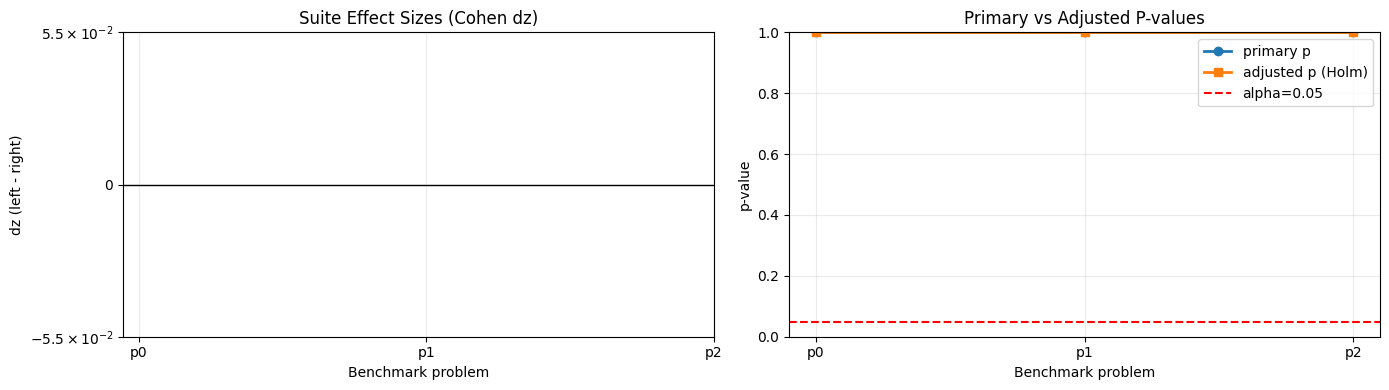

problem label map:
p0: sphere_live_malthusjax_vs_sphere_live_evosax
p1: rastrigin_live_malthusjax_vs_rastrigin_live_evosax
p2: rosenbrock_live_malthusjax_vs_rosenbrock_live_evosax


In [18]:
# Plot 1: Effect size by dataset | Plot 2: Raw vs adjusted p-values
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(len(labels))
short_labels = [f'p{i}' for i in range(len(labels))]

# Effect sizes
axes[0].bar(x, cohen_dz, color='steelblue', alpha=0.85)
axes[0].axhline(0.0, color='black', linewidth=1)
axes[0].set_title('Suite Effect Sizes (Cohen dz)')
axes[0].set_xlabel('Benchmark problem')
axes[0].set_ylabel('dz (left - right)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_labels)
axes[0].set_yscale('symlog', linthresh=1.0)
axes[0].grid(alpha=0.25)

# P-values
axes[1].plot(x, primary_p, marker='o', linewidth=2, label='primary p')
axes[1].plot(x, adjusted_primary, marker='s', linewidth=2, label='adjusted p (Holm)')
axes[1].axhline(spec_location.alpha,
                color='red', linestyle='--',
                label=f'alpha={spec_location.alpha}')
axes[1].set_title('Primary vs Adjusted P-values')
axes[1].set_xlabel('Benchmark problem')
axes[1].set_ylabel('p-value')
axes[1].set_ylim(0.0, 1.0)
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_labels)
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

print('problem label map:')
for i, lbl in enumerate(labels):
    print(f'p{i}: {lbl}')

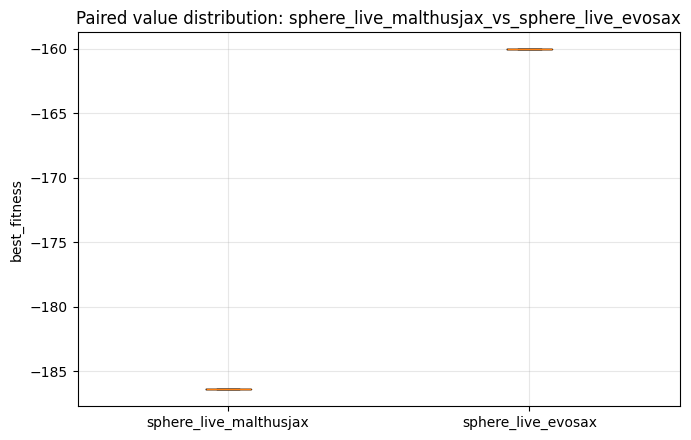

In [20]:
# Paired boxplot for a single benchmark in the suite
k = 0
ds0 = suite_datasets[k]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([ds0.left_values, ds0.right_values],
           tick_labels=[ds0.left_name, ds0.right_name])
ax.set_title(f'Paired value distribution: {ds0.label}')
ax.set_ylabel(ds0.metric_name)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Part 6: Multiple-testing correction helpers

Low-level utilities are exposed directly:
- `adjust_pvalues(p_values, policy)`
- `attach_adjusted_pvalues(results, adjusted, key='primary')`

This is useful when integrating custom test batteries.

In [10]:
raw_p = [0.004, 0.011, 0.031, 0.12, 0.41]
adj_holm = adjust_pvalues(raw_p, MultipleTestingPolicy.HOLM)
adj_fdr = adjust_pvalues(raw_p, MultipleTestingPolicy.FDR_BH)

print('raw p   =', raw_p)
print('holm p  =', [round(v, 6) for v in adj_holm])
print('fdr p   =', [round(v, 6) for v in adj_fdr])

mapping = attach_adjusted_pvalues(suite.results, adjust_pvalues([
    r.tests.get('wilcoxon').p_value if r.tests.get('wilcoxon') else np.nan
    for r in suite.results
], MultipleTestingPolicy.HOLM), key='primary')
print('attached labels:', list(mapping)[:2])

raw p   = [0.004, 0.011, 0.031, 0.12, 0.41]
holm p  = [0.02, 0.044, 0.093, 0.24, 0.41]
fdr p   = [0.02, 0.0275, 0.051667, 0.15, 0.41]
attached labels: ['demo_malthusjax_vs_demo_evosax', 'malthusjax_default_vs_evosax_simplega']


## Part 7: Reporting model

`StatisticalSuiteResult` exposes:
- `to_dict()` for JSON serialization
- `to_markdown()` for human-readable reports

The markdown output can include compact or expanded sections depending on spec flags.

In [11]:
payload = suite.to_dict()
md = suite.to_markdown()

print('dict keys:', list(payload.keys()))
print('spec keys:', list(payload['spec'].keys())[:6])
print('markdown preview:')
print(''.join(md.splitlines()[:16]))

dict keys: ['spec', 'results', 'adjusted_p_values']
spec keys: ['metric_name', 'hypothesis_kind', 'sidedness', 'expected_direction', 'optimum_value', 'equivalence_margin']
markdown preview:
# Statistical Suite Summary| Label | n | Cohen dz | Primary p | Decision | Basis ||---|---:|---:|---:|---|---|| demo_malthusjax_vs_demo_evosax | 1 | nan | 1 | pass | wilcoxon_two-sided || malthusjax_default_vs_evosax_simplega | 30 | 422.829 | 1.86265e-09 | fail | wilcoxon_two-sided || malthusjax_tournament_evosaxops_vs_evosax_mr15_ga | 30 | 16028.3 | 1.86265e-09 | fail | wilcoxon_two-sided || malthusjax_roulette_evosaxops_vs_evosax_differential_evolution | 30 | 7207.53 | 1.86265e-09 | fail | wilcoxon_two-sided || prng_threefry_vs_prng_unsafe_rbg | 1 | nan | 1 | pass | wilcoxon_two-sided |## Progress Context: demo_malthusjax_vs_demo_evosax| Left Start | Right Start | Left Delta | Right Delta | Delta Diff (L-R) ||---:|---:|---:|---:|---:|| -81.7845 | 97.3196 | 33.812 | -29.8463 | 63.6583 |


## Part 8: How this connects to your parity workflow

Typical end-to-end path in this repo:

1. Run TOML experiment with `Composer.from_toml(...)`.
2. Build paired datasets from pipeline pairs with `paired_dataset_from_comparison(...)`.
3. Compare per-problem and suite-level with `StatisticalComparator`.
4. Export markdown and JSON summaries into a results folder.

This is exactly the abstraction used by `scripts/run_toml_statistical_parity.py`.

## Summary

The statistics abstraction gives you:
- one canonical spec object for inferential intent,
- adapter-based dataset construction from different result sources,
- consistent test/effect/decision output objects,
- suite-level correction and reporting with minimal script-specific logic.

It keeps parity analysis reproducible, composable, and easier to maintain as experiments evolve.

## Part 9: Statistical Theory

### Why paired analysis is the default here
Parity comparisons are paired by seed: each seed produces two outcomes under the same problem setup, one per pipeline. This creates a matched design that removes much of the nuisance variability due to seed-level randomness.

If we define per-seed differences as $d_i = L_i - R_i$, inferential tests are then applied to the vector $d$. This generally has higher power than unpaired testing when seed effects are large.

### Mapping research questions to hypothesis kind
- `location_shift`: asks whether typical paired performance differs.
- `closer_to_optimum`: asks which pipeline ends closer to known optimum (distance-based, practically meaningful).
- `equivalence`: asks whether differences are small enough to be practically negligible under a margin.

### Why suite-level correction matters
When comparing across many problems, multiple-testing correction controls false discoveries. This framework applies correction after per-problem paired tests, which avoids invalid raw pooling across heterogeneous problem scales.

## Part 10: Test and Effect Size Interpretation

### Tests in this abstraction
- Wilcoxon signed-rank: robust non-parametric test for paired differences.
- Paired t-test: efficient under approximately normal paired differences.
- Sign test: direction-only signal (wins/losses), ignores magnitude.

### Effect sizes
- Cohen's $d_z = \bar d / s_d$ for paired differences.
- Rank-biserial summarizes directional dominance from positive vs negative differences.

### Interpretation pattern
Use p-values and effect sizes together:
- low p + tiny effect can be statistically significant but practically small,
- moderate p + medium/large effect may indicate insufficient seeds (low power),
- for decision-making, practical magnitude should be explicit in the report.

In [12]:
# Optional helper: qualitative interpretation for Cohen dz
def interpret_cohen_dz(dz: float | None) -> str:
    if dz is None or (isinstance(dz, float) and np.isnan(dz)):
        return 'n/a'
    adz = abs(float(dz))
    if adz < 0.2:
        return 'negligible'
    if adz < 0.5:
        return 'small'
    if adz < 0.8:
        return 'medium'
    return 'large'

for r in suite.results:
    print(r.label, '| dz =', r.effects.cohen_dz, '|', interpret_cohen_dz(r.effects.cohen_dz))

demo_malthusjax_vs_demo_evosax | dz = nan | n/a
malthusjax_default_vs_evosax_simplega | dz = 422.829400574574 | large
malthusjax_tournament_evosaxops_vs_evosax_mr15_ga | dz = 16028.340524910063 | large
malthusjax_roulette_evosaxops_vs_evosax_differential_evolution | dz = 7207.533841741813 | large
prng_threefry_vs_prng_unsafe_rbg | dz = nan | n/a


## Part 11: Equivalence Testing (TOST)

Classical tests answer: "is there a detectable difference?" Equivalence tests answer: "is the difference small enough to be practically negligible?"

With equivalence margin $m > 0$ and paired mean difference $\mu_d$, TOST evaluates two one-sided nulls:
$$
H_{01}: \mu_d \le -m, \qquad H_{02}: \mu_d \ge m
$$
If both are rejected, we conclude $\mu_d \in (-m, m)$ and claim equivalence.

In this module, `HypothesisKind.EQUIVALENCE` routes through paired TOST and decision is based on `p_max < alpha`.

In [13]:
# Equivalence usage example (synthetic)
spec_eq_demo = StatisticalComparisonSpec(
    metric_name='best_fitness',
    hypothesis_kind=HypothesisKind.EQUIVALENCE,
    equivalence_margin=0.06,
    alpha=0.05,
    min_paired_seeds=10,
)

eq_result = comparator.compare_paired(dataset, spec_eq_demo)
print('equivalence decision:', eq_result.decision_pass)
print('decision basis:', eq_result.decision_basis)
if eq_result.tost is not None:
    print('TOST p_max:', eq_result.tost.p_value_max)
    print('equivalence bounds:', (eq_result.tost.lower_bound, eq_result.tost.upper_bound))

equivalence decision: False
decision basis: tost
TOST p_max: 0.8974537063634234
equivalence bounds: (-0.06, 0.06)


## Part 12: Practical Usage Playbook

### Recipe A: Single problem decision
- Build one `PairedMetricDataset`.
- Run `compare_paired(dataset, spec)`.
- Report: decision, primary p-value, Cohen dz, rank-biserial, wins/ties.

### Recipe B: Multi-problem suite
- Build one dataset per problem.
- Run `compare_suite(datasets, spec)`.
- Use `suite.adjusted_p_values` for corrected claims across the suite.

### Recipe C: Closer-to-optimum framing
When practical objective is "which pipeline gets closer to known optimum", set `hypothesis_kind=closer_to_optimum` and provide `optimum_value` if no precomputed gap metric is available.

### Recipe D: Reproducible outputs
- Use `suite.to_markdown()` for thesis/human reporting.
- Use `suite.to_dict()` for machine processing and archive pipelines.

In [14]:
# Usage recipe: build a compact sortable table from suite results
rows = []
for r in suite.results:
    if 'wilcoxon' in r.tests and r.tests['wilcoxon'].p_value is not None:
        primary_p = float(r.tests['wilcoxon'].p_value)
    elif 'paired_t' in r.tests and r.tests['paired_t'].p_value is not None:
        primary_p = float(r.tests['paired_t'].p_value)
    else:
        primary_p = np.nan

    rows.append(
        {
            'label': r.label,
            'n': r.n_paired,
            'cohen_dz': r.effects.cohen_dz,
            'primary_p': primary_p,
            'p_adj_primary': suite.adjusted_p_values.get(r.label, {}).get('primary', np.nan),
            'decision': r.decision_pass,
        }
    )

rows_sorted = sorted(
    rows,
    key=lambda x: (np.nan_to_num(x['p_adj_primary'], nan=1.0),
                   abs(np.nan_to_num(x['cohen_dz'], nan=0.0))),
)

for row in rows_sorted:
    print(row)

{'label': 'malthusjax_default_vs_evosax_simplega', 'n': 30, 'cohen_dz': 422.829400574574, 'primary_p': 1.862645149230957e-09, 'p_adj_primary': 9.313225746154785e-09, 'decision': False}
{'label': 'malthusjax_roulette_evosaxops_vs_evosax_differential_evolution', 'n': 30, 'cohen_dz': 7207.533841741813, 'primary_p': 1.862645149230957e-09, 'p_adj_primary': 9.313225746154785e-09, 'decision': False}
{'label': 'malthusjax_tournament_evosaxops_vs_evosax_mr15_ga', 'n': 30, 'cohen_dz': 16028.340524910063, 'primary_p': 1.862645149230957e-09, 'p_adj_primary': 9.313225746154785e-09, 'decision': False}
{'label': 'demo_malthusjax_vs_demo_evosax', 'n': 1, 'cohen_dz': nan, 'primary_p': 1.0, 'p_adj_primary': 1.0, 'decision': True}
{'label': 'prng_threefry_vs_prng_unsafe_rbg', 'n': 1, 'cohen_dz': nan, 'primary_p': 1.0, 'p_adj_primary': 1.0, 'decision': True}
